<a href="https://colab.research.google.com/github/DanieleBaiocco/nlp_first_assignment/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

## Dataset preparation

In [ ]:
!pip install -q -U keras-tuner

     |████████████████████████████████| 135 kB 14.7 MB/s 
     |████████████████████████████████| 1.6 MB 55.1 MB/s 


In [ ]:
import os
from urllib import request
from zipfile import ZipFile
import numpy as np
import pandas as pd
import sys

import gensim
import pickle
import gensim.downloader as gloader

import copy

from sklearn.preprocessing import LabelBinarizer

In [ ]:
class Dataset():

    def __init__(
        self,
        url,
        preprocessing = True,
        download_folder = "Datasets"
    ):

      self.download_extract_dataset(download_folder, url)
      self.train_list, self.val_list, self.test_list = self.build_splitted_list(download_folder, preprocessing)
      self.max_sentence_size = self.get_max_sentence_size()

    def download_extract_dataset(self, download_folder: str, url: str):
        dataset_folder = os.path.join(os.getcwd(), download_folder)
        dataset_path = os.path.join(dataset_folder, "Corpora.zip")
        if not os.path.exists(dataset_folder):
          os.makedirs(dataset_folder)
        if not os.path.exists(dataset_path):
            print("Downloading and Extracting dataset...")
            request.urlretrieve(url, dataset_path)
            with ZipFile(dataset_path, 'r') as zObject:
                zObject.extractall(
            path=dataset_folder)
            print("Done!")

    def build_splitted_list(self, download_folder: str, preprocessing: bool):
        df_rows = []

        train_list = []
        val_list = []
        test_list = []

        dataset_folder = os.path.join(os.getcwd(), download_folder, "dependency_treebank")
        list_dir = os.listdir(dataset_folder)
        list_dir.sort()

        doc_number = 1
        doc_classification = self.doc_classification(doc_number)
        
        for dir in list_dir:
            file_path = os.path.join(dataset_folder, dir)               
            if os.path.isfile(file_path):
                with open(file_path, mode = 'r', encoding = 'utf-8') as text_file:
                  critical_line = 0
                  df_row = []
                  lines = text_file.readlines()
                  for count, line in enumerate(lines):
                      splitted_line = line.split()
                      if len(splitted_line) != 3 or count + 1 >= len(lines):
                          if doc_classification == 'train':
                              train_list.append(df_row)
                          elif doc_classification == 'val':
                              val_list.append(df_row)
                          elif doc_classification == 'test':
                              test_list.append(df_row)
                          df_row = []
                          critical_line = count + 1
                          if count + 1 >= len(lines):
                              doc_number += 1
                      else:
                        if count == critical_line:
                            doc_classification = self.doc_classification(doc_number)
                        df_row.append(
                            (self.preprocessing(splitted_line[0]) if preprocessing else splitted_line[0], 
                             splitted_line[1])
                            )

        return train_list, val_list, test_list

    def doc_classification(self, doc_number):
        if doc_number <= 100:
            split = 'train'
        elif 100 < doc_number <=150:
            split= 'val'
        else: 
            split = 'test'
        return split 
    
    def preprocessing(self, word):
        wordtr = ""
        splitted_word = word.split('-')
        if len(splitted_word) > 1:
          wordtr = splitted_word[1]
        else: wordtr = splitted_word[0]
        #try:
        #    float(wordtr)
        #    wordtr = '36'
        #except ValueError:
        #   pass
        return wordtr.lower()
    
    def get_max_sentence_size(self):
        return max([len(x) for x in self.train_list + self.val_list + self.test_list])

In [ ]:
url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/dependency_treebank.zip"
data = Dataset(url = url)

Done!


## Data Analysis 

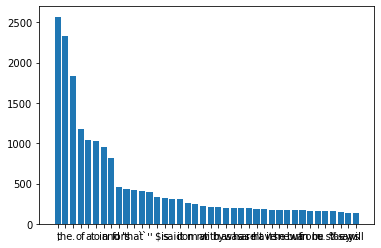

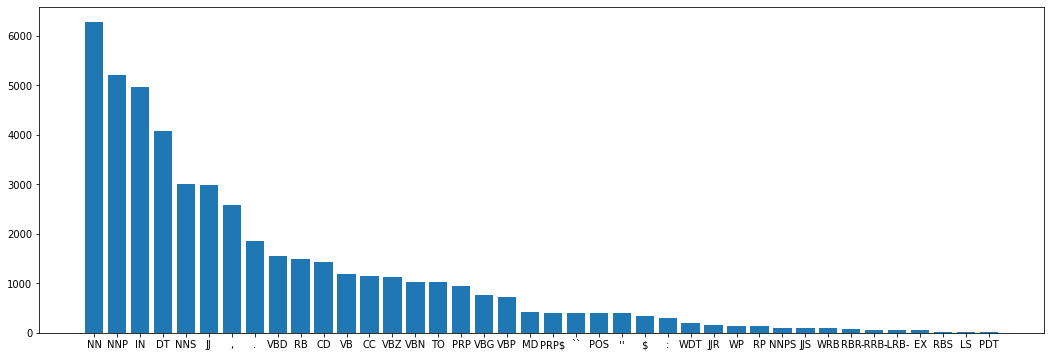

In [ ]:
from collections import Counter
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

def create_corpus(data):
    words = []
    labels = []
    for sentence in data:
        for word in sentence:
            words.append(word[0])
            labels.append(word[1])
    return words, labels

words, labels = create_corpus(data.train_list)

def plot_counts(data, results_num: int):
    dic=defaultdict(int)
    for word in data:
        dic[word]+=1

    top=sorted(dic.items(), key=lambda x:x[1],reverse=True)[:results_num] 
    figure = plt.figure()
    plt.rcParams['figure.figsize'] = (18.0, 6.0)
    plt.xlabel = 'Words'
    plt.ylabel = 'Count of occurencies in dataset'
    x,y=zip(*top)
    plt.bar(x,y, label = 'Count of occurencies in dataset')
    figure.show()

plot_counts(words, 40)
plot_counts(labels, 40)

In [ ]:
class Embedder():
  
    def __init__(
        self,
        data: Dataset,
        embedding_dimension = 100,
    ):
        self.embedding_model = self.load_embedding_model(embedding_dimension)
        self.embedding_dimension = embedding_dimension
        
        v1 = self.embedding_model
        oov_terms_train = self.check_OOV_terms(v1, data.train_list, "1")
        v2 = self.add_OOV_terms(v1, oov_terms_train, embedding_dimension)
        oov_terms_val = self.check_OOV_terms(v2, data.val_list, "2")
        v3 = self.add_OOV_terms(v2, oov_terms_val, embedding_dimension)
        oov_terms_test = self.check_OOV_terms(v3, data.test_list, "3")
        v4 = self.add_OOV_terms(v3, oov_terms_test, embedding_dimension)

        print(1)
        enc_X_train, y_train = self.build_embeddings_df(v2, data.train_list, embedding_dimension, data.max_sentence_size)
        enc_X_val, y_val = self.build_embeddings_df(v3, data.val_list, embedding_dimension, data.max_sentence_size)
        enc_X_test, y_test = self.build_embeddings_df(v4, data.test_list, embedding_dimension, data.max_sentence_size)

        print(2)
        self.encoder = LabelBinarizer()
        enc_y_train = self.one_hot_encode(y_train, data.max_sentence_size, is_fit = True)
        enc_y_val = self.one_hot_encode(y_val, data.max_sentence_size)
        enc_y_test = self.one_hot_encode(y_test, data.max_sentence_size)

        self.X_train = enc_X_train
        self.X_val = enc_X_val
        self.X_test = enc_X_test
        self.y_train = enc_y_train
        self.y_val = enc_y_val
        self.y_test = enc_y_test

    def load_embedding_model(self, embedding_dimension = 100):
        loading_dir_path = os.path.join(os.getcwd(), "embedding_model")
        loading_model_path = os.path.join(loading_dir_path, "model.bin")
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
        emb_model = gloader.load(download_path)
        return emb_model 

    def check_OOV_terms(self, vocabulary, dataset, v_num):
        embedding_vocabulary = set(vocabulary.vocab.keys())
        word_listing = set()
        for sentence in dataset:
          for couple in sentence:
            word, _ = couple
            word_listing.add(word)
        oov = word_listing.difference(embedding_vocabulary)

        oov_percentage = float(len(list(oov))) * 100 / len(word_listing)
        print(f"Total OOV terms in V{v_num}: {len(list(oov))} ({oov_percentage:.2f}%)")
        return list(oov)

    def add_OOV_terms(self, vocabulary, oov, embedding_dim):
        voc = copy.deepcopy(vocabulary)
        for word in oov:
          voc[word] = np.random.uniform(-1, 1, size=embedding_dim)
        print(f"Generated embeddings for {len(oov)} OOV words.")
        return voc

    def build_embeddings_df(self, vocabulary, df, embedding_dimension, max_sentence_size):
        df_rows = []
        ys = []
        for sentence in df:
          embeddings_row = np.array([vocabulary[word] for word, _ in sentence])
          df_rows.append(
              np.vstack(
                  (
                  embeddings_row,
                  np.zeros((max_sentence_size - len(sentence), embedding_dimension)),
                  )
              )
          )
          y = [target for _, target in sentence]
          ys.append(y)

        
        return np.array(df_rows), np.array(ys)

    def one_hot_encode(self, y, max_sentence_size, is_fit = False):
        y_onehot = []

        if is_fit:
          self.encoder.fit([word for sentence in y for word in sentence])

        for sentence in y:
          y_onehot_row = self.encoder.transform(sentence)
          padding_row = np.zeros((max_sentence_size - len(y_onehot_row), len(self.encoder.classes_)))
          y_onehot.append(
              np.vstack(
                  ( 
                    y_onehot_row,
                    padding_row,  
                  )
              )
          )
        return np.array(y_onehot)

In [ ]:
embedded_data = Embedder(data)

[==================================================] 100.0% 128.1/128.1MB downloaded
Total OOV terms in V1: 157 (2.22%)
Generated embeddings for 157 OOV words.
Total OOV terms in V2: 81 (1.55%)
Generated embeddings for 81 OOV words.
Total OOV terms in V3: 68 (2.07%)
Generated embeddings for 68 OOV words.
1


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


2


In [ ]:
from keras import Sequential, Input, optimizers
import keras_tuner as kt
from keras.layers import Dense, Bidirectional, LSTM, Activation, TimeDistributed, Embedding, GRU, Masking, GlobalMaxPool1D, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping

embedding_dimension = 100
num_classes = 45
input_shape = (data.max_sentence_size, embedding_dimension)

def baseline_model(hp):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    hp_units = hp.Choice('units', values=[64, 128, 256])
    hp_dropout = hp.Choice('dropout', values=[0.0, 0.1, 0.2, 0.3])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.add(Bidirectional(LSTM(hp_units, return_sequences = True)))
    model.add(Dropout(rate=hp_dropout))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    model.compile(loss='categorical_crossentropy', optimizer = optimizers.Adam(learning_rate = hp_learning_rate), metrics=["accuracy"])
    return model

def two_dense_model(hp):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    hp_units1 = hp.Choice('lstm_units', values=[64, 128, 256])
    hp_units2 = hp.Choice('dense_units', values=[64, 128, 256])
    hp_dropout1 = hp.Choice('dropout1', values=[0.0, 0.1, 0.2])
    hp_dropout2 = hp.Choice('dropout2', values=[0.0, 0.1, 0.2])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.add(Bidirectional(LSTM(hp_units1, return_sequences = True)))
    model.add(Dropout(rate=hp_dropout1))
    model.add(TimeDistributed(Dense(units=hp_units2, activation = 'relu')))
    model.add(Dropout(rate=hp_dropout2))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    model.compile(loss='categorical_crossentropy', optimizer = optimizers.Adam(learning_rate = hp_learning_rate), metrics=["accuracy"])
    return model

def two_lstm_model(hp):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    hp_units1 = hp.Choice('units1', values=[64, 128, 256])
    hp_units2 = hp.Choice('units2', values=[64, 128, 256])
    hp_dropout = hp.Choice('dropout', values=[0.0, 0.1, 0.2])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.add(Bidirectional(LSTM(hp_units1, return_sequences = True)))
    model.add(Bidirectional(LSTM(hp_units2, return_sequences = True)))
    model.add(Dropout(rate=hp_dropout))

    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))
    
    model.compile(loss='categorical_crossentropy', optimizer = optimizers.Adam(learning_rate = hp_learning_rate), metrics=["accuracy"])
    return model

def GRU_model(hp):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    hp_units = hp.Choice('units', values=[64, 128, 256])
    hp_dropout = hp.Choice('dropout', values=[0.0, 0.1, 0.2])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.add(Bidirectional(GRU(hp_units, return_sequences = True)))
    model.add(Dropout(rate=hp_dropout))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    
    model.compile(loss='categorical_crossentropy', optimizer = optimizers.Adam(learning_rate = hp_learning_rate), metrics=["accuracy"])
    return model

In [ ]:
baseline_tuner = kt.Hyperband(baseline_model,
                     objective='val_accuracy',
                     directory='baseline',
                     project_name='trial1',
                     seed = 47)

two_dense_tuner = kt.Hyperband(two_dense_model,
                     objective='val_accuracy',
                     directory='two_dense',
                     project_name='trial1',
                     seed = 47)

gru_tuner = kt.Hyperband(GRU_model,
                     objective='val_accuracy',
                     directory='gru',
                     project_name='trial1',
                     seed = 47)

two_lstm_tuner = kt.Hyperband(two_lstm_model,
                     objective='val_accuracy',
                     directory='two_lstm',
                     project_name='trial1',
                     seed = 47)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=True
)

In [ ]:
baseline_tuner.search(embedded_data.X_train, embedded_data.y_train, batch_size = 64, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[early_stopping])

Trial 36 Complete [00h 00m 17s]
val_accuracy: 0.7264959812164307

Best val_accuracy So Far: 0.9042173624038696
Total elapsed time: 00h 50m 42s


In [ ]:
gru_tuner.search(embedded_data.X_train, embedded_data.y_train, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[early_stopping])

Trial 27 Complete [00h 00m 17s]
val_accuracy: 0.9006199240684509

Best val_accuracy So Far: 0.9030289649963379
Total elapsed time: 00h 08m 26s


In [ ]:
two_dense_tuner.search(embedded_data.X_train, embedded_data.y_train, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[early_stopping])

Trial 254 Complete [00h 01m 47s]
val_accuracy: 0.8811550736427307

Best val_accuracy So Far: 0.9245495200157166
Total elapsed time: 01h 48m 39s


In [ ]:
two_lstm_tuner.search(embedded_data.X_train, embedded_data.y_train, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[early_stopping])

Trial 74 Complete [00h 00m 32s]
val_accuracy: 0.8278996348381042

Best val_accuracy So Far: 0.9083930253982544
Total elapsed time: 00h 42m 05s


In [ ]:
# Get the optimal hyperparameters
baseline_best_hps = baseline_tuner.get_best_hyperparameters()[0]

print(f"""The hyperparameter search for the baseline model is complete.""")
print(f"""The optimal number of units in the first LSTM layer is {baseline_best_hps.get('units')}.""")
print(f"""The optimal rate in the dropout layer is {baseline_best_hps.get('dropout')}.""")
print(f"""The optimal learning rate for the optimizer is {baseline_best_hps.get('learning_rate')}.""")

The hyperparameter search for the baseline model is complete.
The optimal number of units in the first LSTM layer is 256.
The optimal rate in the dropout layer is 0.0.
The optimal learning rate for the optimizer is 0.01.


In [ ]:
# Get the optimal hyperparameters
gru_best_hps = gru_tuner.get_best_hyperparameters()[0]

print(f"""The hyperparameter search for the GRU model is complete.""")
print(f"""The optimal number of units in the first GRU layer is {gru_best_hps.get('units')}.""")
print(f"""The optimal rate in the dropout layer is {gru_best_hps.get('dropout')}.""")
print(f"""The optimal learning rate for the optimizer is {gru_best_hps.get('learning_rate')}.""")

The hyperparameter search for the GRU model is complete.
The optimal number of units in the first GRU layer is 256.
The optimal rate in the dropout layer is 0.1.
The optimal learning rate for the optimizer is 0.01.


In [ ]:
# Get the optimal hyperparameters
two_dense_best_hps = two_dense_tuner.get_best_hyperparameters()[0]

print(f"""The hyperparameter search for the Two Dense model is complete.""")
print(f"""The optimal number of units in the first LSTM layer is {two_dense_best_hps.get('lstm_units')}.""")
print(f"""The optimal number of units in the first dense layer is {two_dense_best_hps.get('dense_units')}.""")
print(f"""The optimal rate in the first dropout layer is {two_dense_best_hps.get('dropout1')}.""")
print(f"""The optimal rate in the second dropout layer is {two_dense_best_hps.get('dropout2')}.""")
print(f"""The optimal learning rate for the optimizer is {two_dense_best_hps.get('learning_rate')}.""")

The hyperparameter search for the Two Dense model is complete.
The optimal number of units in the first LSTM layer is 128.
The optimal number of units in the first dense layer is 64.
The optimal rate in the first dropout layer is 0.2.
The optimal rate in the second dropout layer is 0.2.
The optimal learning rate for the optimizer is 0.01.


In [ ]:
# Get the optimal hyperparameters
two_lstm_best_hps = two_lstm_tuner.get_best_hyperparameters()[0]

print(f"""The hyperparameter search for the Two LSTM model is complete.""")
print(f"""The optimal number of units in the first LSTM layer is {two_lstm_best_hps.get('units1')}.""")
print(f"""The optimal number of units in the second LSTM layer is {two_lstm_best_hps.get('units2')}.""")
print(f"""The optimal rate in the dropout layer is {two_lstm_best_hps.get('dropout')}.""")
print(f"""The optimal learning rate for the optimizer is {two_lstm_best_hps.get('learning_rate')}.""")

The hyperparameter search for the Two LSTM model is complete.
The optimal number of units in the first LSTM layer is 256.
The optimal number of units in the second LSTM layer is 128.


KeyError: ignored

In [ ]:
cb_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.05,
    patience=3,
    restore_best_weights=True,
    verbose=True
)

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
baseline_model = baseline_tuner.hypermodel.build(baseline_best_hps)
baseline_model.summary()
baseline_history = baseline_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=64, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[cb_early_stopping])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_1 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 249, 512)         731136    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 249, 512)          0         
                                                                 
 time_distributed_1 (TimeDis  (None, 249, 45)          23085     
 tributed)                                                       
                                                                 
Total params: 754,221
Trainable params: 754,221
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
31/31 [==============================

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
gru_model = gru_tuner.hypermodel.build(gru_best_hps)
gru_model.summary()
gru_history = gru_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[cb_early_stopping])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_2 (Masking)         (None, 249, 300)          0         
                                                                 
 bidirectional_3 (Bidirectio  (None, 249, 512)         857088    
 nal)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 249, 512)          0         
                                                                 
 time_distributed_2 (TimeDis  (None, 249, 45)          23085     
 tributed)                                                       
                                                                 
Total params: 880,173
Trainable params: 880,173
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
62/62 [==============================

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
two_dense_model = two_dense_tuner.hypermodel.build(two_dense_best_hps)
baseline_model.summary()
baseline_history = two_dense_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[cb_early_stopping])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_1 (Masking)         (None, 249, 300)          0         
                                                                 
 bidirectional_2 (Bidirectio  (None, 249, 512)         1140736   
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 249, 512)          0         
                                                                 
 time_distributed_1 (TimeDis  (None, 249, 45)          23085     
 tributed)                                                       
                                                                 
Total params: 1,163,821
Trainable params: 1,163,821
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
62/62 [==========================

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
two_lstm_model = two_lstm_tuner.hypermodel.build(two_lstm_best_hps)
two_lstm_model.summary()
two_lstm_history = two_lstm_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[cb_early_stopping])

NameError: ignored

In [ ]:
#scegliere i due modelli migliori

In [ ]:
import matplotlib.pyplot as plt

def plot_history(model_history,keys):
    m,val_m = keys
    plt.plot(model_history.history[m])
    plt.plot(model_history.history[val_m])
    # plt.ylabel(m)
    # plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


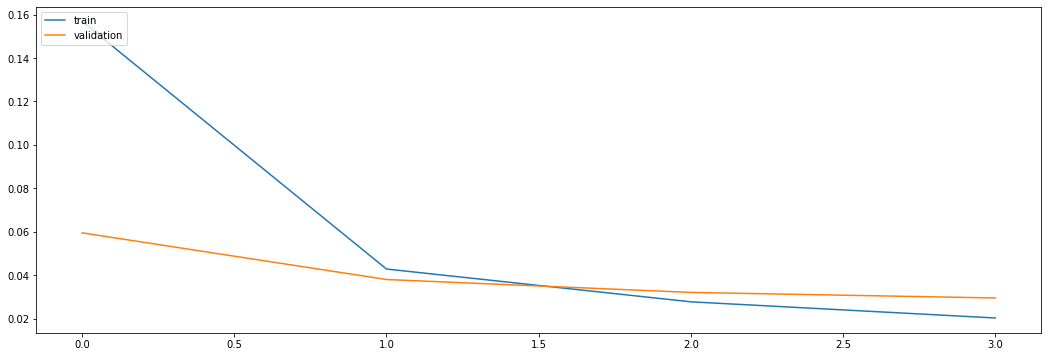

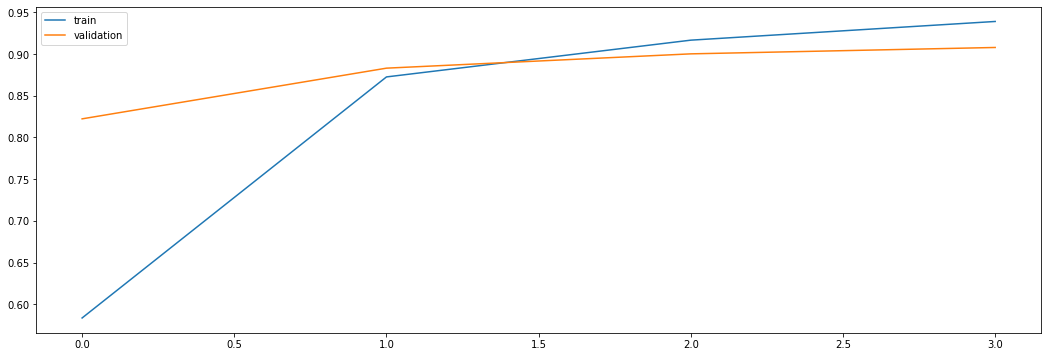

In [ ]:
#baseline
plot_history(baseline_history, ['loss','val_loss'])
plot_history(baseline_history, ['accuracy','val_accuracy'])

In [ ]:
from sklearn.metrics import f1_score

y_true = embedded_data.y_test
y_pred = baseline_model.predict(embedded_data.X_test)

21/21 [==============================] - 3s 9ms/step


In [ ]:
#  MODIFICARE NOMI

def prob_to_onehot(predictions):
  for sentence in predictions:
    for tag in sentence:
      max = np.argmax(np.array(tag))
      tag[max] = 1
      tag[tag!=1] = 0
  return predictions

def cut(y):
  y_cut = []
  for i, sentence in enumerate(data.test_list):
      y_cut.append(y[i][0:len(sentence)])
  return y_cut

def inverseTransform(y):
  y_cut = []
  for i in range(len(data.test_list)):
      y_cut.append(embedded_data.encoder.inverse_transform(y[i]))
  return y_cut

def remove_symbols():
  symbs = ['#', '$', "''", ',', '-LRB-', '-RRB-', '.', ':', 'LS', '``']
  labels = list(embedded_data.encoder.classes_)
  for sym in symbs:
    labels.remove(sym)
  return labels

true_labels = remove_symbols()
y_pred_oh = prob_to_onehot(y_pred)

In [ ]:
y_true_trans = np.array(inverseTransform(y_true))
y_pred_trans = np.array(inverseTransform(y_pred_oh))

**F1-score deve essere calcolato su le liste trasformate: da one hot encoding a string tags**

In [ ]:
f1_score(y_true_trans.flatten(), y_pred_trans.flatten(), labels = true_labels, average='macro', zero_division=0)

0.6796260715504614

**La funzione cut rimuove il padding, riportando gli array alla dimensione della frase originale**

In [ ]:
y_pred_trans_cut = cut(y_pred_trans)
y_true_trans_cut = cut(y_true_trans)

print("Sentence: {}".format(data.test_list[0]))
print("True tags: {}".format(y_true_trans_cut[3]))
print("Predicted tags: {}".format(y_pred_trans_cut[3]))

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
report =  classification_report(y_true_trans.flatten(), y_pred_trans.flatten(), zero_division=0)

In [ ]:
print(report)

In [ ]:
conf_matrix = confusion_matrix(y_true_trans.flatten(), y_pred_trans.flatten(), labels=true_labels)

In [ ]:
disp = ConfusionMatrixDisplay(conf_matrix, display_labels = true_labels)
fig, ax = plt.subplots(figsize=(15,15))
disp.plot(ax=ax)